# GraphResponsa — Stima dei costi e analisi di breakeven

Questo notebook stima i **costi fissi** (infrastruttura AWS + Neo4j Aura) e
**variabili** (Anthropic Claude, Voyage AI, ...) di GraphResponsa, e li mette
in rapporto a tre **possibili prezzi di abbonamento** (€25, €50, €100 al mese —
tre scenari alternativi, non tre piani/tier contemporanei: ogni scenario
assume che *tutti* gli abbonati paghino quel prezzo).

Aggiunge inoltre un'analisi di **scaling**: oltre quanti abbonati la capacita'
attuale di alcuni servizi AWS (in particolare ECS Fargate e Neo4j Aura) non
basta piu' e serve aumentarla, con l'impatto sui costi fissi.

**Assunzione di base (dal committente):** ogni abbonamento include 100
messaggi al mese e si assume che ogni utente li esaurisca tutti, ogni mese
(scenario di costo variabile massimo).

**Fonti usate** (nessun numero e' inventato senza citare da dove viene):
- `aws/infrastruttura.yaml` — stack di produzione realmente in uso (ECS
  Fargate + ALB + CloudFront + DynamoDB + Cognito; Neo4j **Aura gestito**,
  fuori da questo stack). `aws/cloudformation.yaml` (EC2 + Neo4j Community
  self-hosted) e' un'alternativa **non usata** in produzione.
- `src/agente/agente.py` — modello `claude-haiku-4-5`, prezzi $1/$5 per MTok
  input/output, token di cache: scrittura x1,25, lettura x0,10.
- `docs/report-2026-09-08.md` — costo per domanda misurato in produzione
  ($0,0206–$0,026), latenza per consultazione (8s mediana, 13s p90, 22s
  worst-case), chiamate a strumenti per domanda (2,6 corrette, 3,1 errate).
- `docs/architettura-knowledge-graph.md` — dimensione del dataset su Aura
  (~0,8 GB), costo di indicizzazione Voyage AI.

**Cosa NON e' verificato e va controllato prima di usare questi numeri per
decisioni reali** (segnalato anche nelle celle sotto): il tasso di cambio
USD→EUR, il tier/tariffa reale dell'istanza Neo4j Aura in uso, e la capacita'
per tier di Aura (non pubblicata nel repository — qui e' un'ipotesi
illustrativa per mostrare la forma della curva di scaling, da tarare con un
load test reale).


In [ ]:
%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

EUR_FMT = mticker.FuncFormatter(lambda x, pos: f"€{x:,.0f}".replace(",", "."))


## 1. Assunzioni economiche

Tutti i parametri modificabili sono raccolti qui. Cambiando un valore, tutto
il notebook a valle si ricalcola (basta rieseguire le celle).


In [2]:
# --- Assunzioni "commerciali" -------------------------------------------
FX_USD_EUR = 0.93            # ASSUNZIONE: verificare il cambio corrente
MSG_INCLUSI_MESE = 100       # richiesta utente
PREZZI_EUR = [25, 50, 100]   # tre SCENARI di prezzo alternativi, non tier

# --- Costo variabile per messaggio, per driver (USD) ---------------------
# Claude (claude-haiku-4-5): misurato in produzione $0,0206/domanda (benchmark,
# costo corretto) - $0,026/domanda (produzione, report 2026-09-08, "~2,6
# centesimi/domanda, praticamente tutti di Claude"). Prezzi modello in
# src/agente/agente.py: $1/$5 per MTok input/output; cache: scrittura x1,25,
# lettura x0,10.
COSTO_CLAUDE_MSG_USD = 0.023

# Voyage AI (voyage-4): ~20 token/domanda (docs/architettura-agente.md §6.2).
# Costo derivato da 07_embeddings.py: $1,07 per 17,8 M token indicizzati
# (docs/architettura-knowledge-graph.md) ⇒ ~$0,06/MTok. Trascurabile.
COSTO_VOYAGE_MSG_USD = 0.0000012

# Amazon DynamoDB (on-demand): stima poche unita' RCU/WCU per messaggio
# scambiato (checkpoint conversazione, tabelle checkpoint/scritture/consumi).
COSTO_DYNAMODB_MSG_USD = 0.00005

# CloudFront + trasferimento dati: stima prudenziale per pochi KB per
# richiesta/risposta (streaming SSE).
COSTO_CLOUDFRONT_MSG_USD = 0.0005

driver_variabili = pd.DataFrame([
    ("Claude (claude-haiku-4-5)", COSTO_CLAUDE_MSG_USD),
    ("Voyage AI (voyage-4)", COSTO_VOYAGE_MSG_USD),
    ("Amazon DynamoDB (on-demand)", COSTO_DYNAMODB_MSG_USD),
    ("CloudFront + trasferimento dati", COSTO_CLOUDFRONT_MSG_USD),
], columns=["driver", "usd_per_messaggio"])

COSTO_VAR_MSG_USD = driver_variabili["usd_per_messaggio"].sum()
COSTO_VAR_MSG_EUR = COSTO_VAR_MSG_USD * FX_USD_EUR
COSTO_VAR_UTENTE_MESE_EUR = COSTO_VAR_MSG_EUR * MSG_INCLUSI_MESE

driver_variabili["eur_per_messaggio"] = driver_variabili["usd_per_messaggio"] * FX_USD_EUR
display(driver_variabili.style.format({"usd_per_messaggio": "${:.7f}", "eur_per_messaggio": "€{:.7f}"}))

print(f"Costo variabile totale per messaggio: ${COSTO_VAR_MSG_USD:.5f} = €{COSTO_VAR_MSG_EUR:.5f}")
print(f"Costo variabile per utente al mese ({MSG_INCLUSI_MESE} messaggi): €{COSTO_VAR_UTENTE_MESE_EUR:.4f}")


,driver,usd_per_messaggio,eur_per_messaggio
0,Claude (claude-haiku-4-5),$0.0230000,€0.0213900
1,Voyage AI (voyage-4),$0.0000012,€0.0000011
2,Amazon DynamoDB (on-demand),$0.0000500,€0.0000465
3,CloudFront + trasferimento dati,$0.0005000,€0.0004650


Costo variabile totale per messaggio: $0.02355 = €0.02190
Costo variabile per utente al mese (100 messaggi): €2.1903


## 2. Costi fissi mensili (baseline: 1 task Fargate, 1 istanza Aura)

Corrisponde alla configurazione di default di `aws/infrastruttura.yaml`
(`CpuTask=512` = 0,5 vCPU, `MemoriaTask=1024` = 1 GB, `NumeroTask=1`) più
l'istanza Neo4j Aura gestita separatamente.


In [3]:
COSTO_FARGATE_TASK_USD = (0.5 * 0.04048 + 1 * 0.004445) * 730   # 0,5 vCPU / 1 GB, 24/7
COSTO_ALB_USD = 0.0225 * 730 + 5                                 # canone + LCU stimate a basso traffico
COSTO_AURA_USD = 65                                              # STIMA DA VERIFICARE (console Aura)

costi_fissi = pd.DataFrame([
    ("Amazon ECS Fargate", "1 task, 0,5 vCPU / 1 GB RAM, 24/7 (infrastruttura.yaml)", COSTO_FARGATE_TASK_USD),
    ("Application Load Balancer", "Canone orario + LCU stimate (traffico contenuto)", COSTO_ALB_USD),
    ("Amazon CloudFront", "Distribuzione PriceClass_100, traffico base", 2.0),
    ("Amazon S3", "Bucket frontend + archivio (con transizione a IA)", 1.0),
    ("AWS Secrets Manager", "1 segreto (credenziali Aura, chiavi API)", 0.4),
    ("Amazon CloudWatch Logs", "Ingestione + storage, ritenzione 30 giorni", 1.0),
    ("Amazon ECR", "Registro immagini, ultime 10 conservate", 0.5),
    ("Amazon DynamoDB", "6 tabelle, pay-per-request (nessun costo minimo)", 0.0),
    ("Amazon Cognito", "User Pool a inviti (gratuito sotto soglia MAU)", 0.0),
], columns=["voce", "dettaglio", "usd_mese"])

ALTRI_FISSI_USD = costi_fissi.loc[costi_fissi.voce != "Amazon ECS Fargate", "usd_mese"].sum()
# (= tutto tranne Fargate; serve alla sezione 4 per ricomporre il costo a gradini)

costi_fissi["eur_mese"] = costi_fissi["usd_mese"] * FX_USD_EUR
subtot_aws_usd = costi_fissi["usd_mese"].sum()
subtot_aws_eur = costi_fissi["eur_mese"].sum()

riga_aura = pd.DataFrame([["Neo4j Aura (gestito, fuori dallo stack CloudFormation)",
                           "STIMA DA VERIFICARE: dataset ~0,8 GB, tier non confermato nel repo",
                           COSTO_AURA_USD, COSTO_AURA_USD * FX_USD_EUR]],
                          columns=costi_fissi.columns)

tabella_fissi = pd.concat([costi_fissi, riga_aura], ignore_index=True)
display(tabella_fissi.style.format({"usd_mese": "${:.2f}", "eur_mese": "€{:.2f}"}))

TOTALE_FISSO_USD = subtot_aws_usd + COSTO_AURA_USD
TOTALE_FISSO_EUR = subtot_aws_eur + COSTO_AURA_USD * FX_USD_EUR
print(f"Subtotale infrastruttura AWS: ${subtot_aws_usd:.2f} = €{subtot_aws_eur:.2f}")
print(f"TOTALE COSTI FISSI MENSILI (AWS + Aura): ${TOTALE_FISSO_USD:.2f} = €{TOTALE_FISSO_EUR:.2f}")


,voce,dettaglio,usd_mese,eur_mese
0,Amazon ECS Fargate,"1 task, 0,5 vCPU / 1 GB RAM, 24/7 (infrastruttura.yaml)",$18.02,€16.76
1,Application Load Balancer,Canone orario + LCU stimate (traffico contenuto),$21.43,€19.93
2,Amazon CloudFront,"Distribuzione PriceClass_100, traffico base",$2.00,€1.86
3,Amazon S3,Bucket frontend + archivio (con transizione a IA),$1.00,€0.93
4,AWS Secrets Manager,"1 segreto (credenziali Aura, chiavi API)",$0.40,€0.37
5,Amazon CloudWatch Logs,"Ingestione + storage, ritenzione 30 giorni",$1.00,€0.93
6,Amazon ECR,"Registro immagini, ultime 10 conservate",$0.50,€0.47
7,Amazon DynamoDB,"6 tabelle, pay-per-request (nessun costo minimo)",$0.00,€0.00
8,Amazon Cognito,User Pool a inviti (gratuito sotto soglia MAU),$0.00,€0.00
9,"Neo4j Aura (gestito, fuori dallo stack CloudFormation)","STIMA DA VERIFICARE: dataset ~0,8 GB, tier non confermato nel repo",$65.00,€60.45


Subtotale infrastruttura AWS: $44.35 = €41.24
TOTALE COSTI FISSI MENSILI (AWS + Aura): $109.35 = €101.69


## 3. Breakeven a costi fissi costanti, per tre possibili prezzi

I tre prezzi (**€25, €50, €100**) sono **scenari alternativi**: in ognuno
*tutti* gli abbonati pagano lo stesso prezzo. Non sono piani "Base/Pro" da
sommare fra loro. Il costo (fisso + variabile) è identico nei tre scenari:
cambia solo il prezzo applicato, quindi il punto di pareggio.


In [4]:
def tabella_breakeven(n_values, prezzi_eur, fisso_eur, var_utente_eur):
    df = pd.DataFrame({"n_abbonati": n_values})
    df["costi_totali_eur"] = fisso_eur + df["n_abbonati"] * var_utente_eur
    for p in prezzi_eur:
        df[f"ricavi_{p}"] = df["n_abbonati"] * p
        df[f"utile_{p}"] = df[f"ricavi_{p}"] - df["costi_totali_eur"]
    return df

n_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50,
            75, 100, 150, 200, 250, 300, 400, 500]

be = tabella_breakeven(n_values, PREZZI_EUR, TOTALE_FISSO_EUR, COSTO_VAR_UTENTE_MESE_EUR)

print("Punto di pareggio (abbonati necessari), costi fissi costanti:")
for p in PREZZI_EUR:
    n_pareggio = math.ceil(TOTALE_FISSO_EUR / (p - COSTO_VAR_UTENTE_MESE_EUR))
    print(f"  Prezzo €{p}/mese  ->  {n_pareggio} abbonati")

display(be.head(15).style.format({c: "€{:.0f}".format for c in be.columns if c != "n_abbonati"}))


Punto di pareggio (abbonati necessari), costi fissi costanti:
  Prezzo €25/mese  ->  5 abbonati
  Prezzo €50/mese  ->  3 abbonati
  Prezzo €100/mese  ->  2 abbonati


,n_abbonati,costi_totali_eur,ricavi_25,utile_25,ricavi_50,utile_50,ricavi_100,utile_100
0,0,€102,€0,€-102,€0,€-102,€0,€-102
1,1,€104,€25,€-79,€50,€-54,€100,€-4
2,2,€106,€50,€-56,€100,€-6,€200,€94
3,3,€108,€75,€-33,€150,€42,€300,€192
4,4,€110,€100,€-10,€200,€90,€400,€290
5,5,€113,€125,€12,€250,€137,€500,€387
6,6,€115,€150,€35,€300,€185,€600,€485
7,7,€117,€175,€58,€350,€233,€700,€583
8,8,€119,€200,€81,€400,€281,€800,€681
9,9,€121,€225,€104,€450,€329,€900,€779


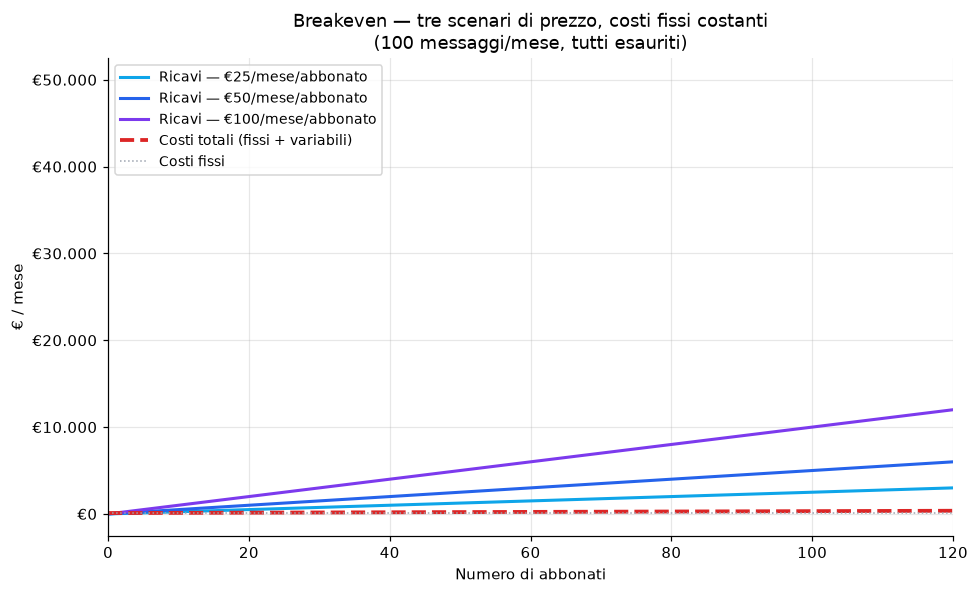

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {25: "#0EA5E9", 50: "#2563EB", 100: "#7C3AED"}
for p in PREZZI_EUR:
    ax.plot(be["n_abbonati"], be[f"ricavi_{p}"], color=colors[p], lw=2,
            label=f"Ricavi — €{p}/mese/abbonato")
ax.plot(be["n_abbonati"], be["costi_totali_eur"], color="#DC2626", lw=2.5, ls="--",
        label="Costi totali (fissi + variabili)")
ax.axhline(TOTALE_FISSO_EUR, color="#9CA3AF", lw=1, ls=":", label="Costi fissi")
ax.set_xlabel("Numero di abbonati")
ax.set_ylabel("€ / mese")
ax.yaxis.set_major_formatter(EUR_FMT)
ax.set_title("Breakeven — tre scenari di prezzo, costi fissi costanti\n(100 messaggi/mese, tutti esauriti)")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 120)
plt.tight_layout()
plt.show()


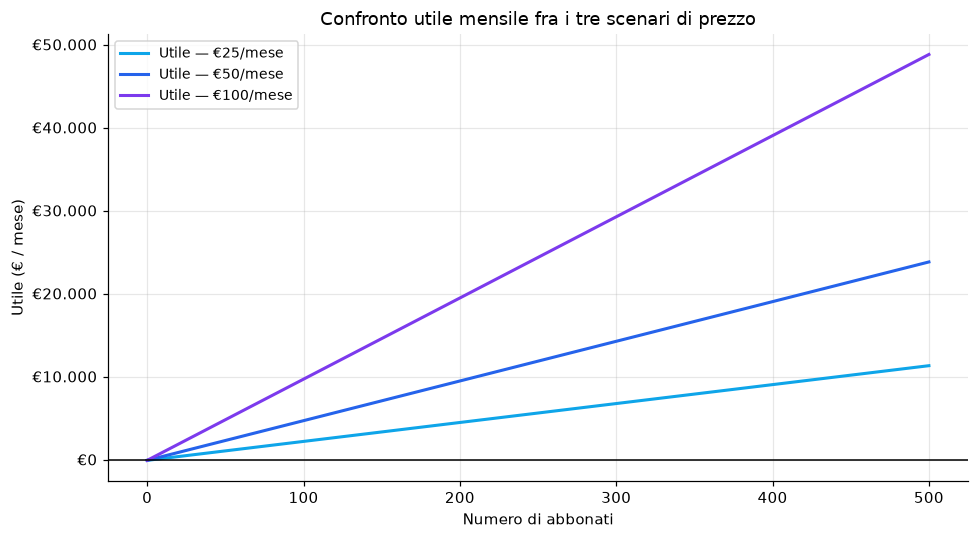

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for p in PREZZI_EUR:
    ax.plot(be["n_abbonati"], be[f"utile_{p}"], color=colors[p], lw=2, label=f"Utile — €{p}/mese")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Numero di abbonati")
ax.set_ylabel("Utile (€ / mese)")
ax.yaxis.set_major_formatter(EUR_FMT)
ax.set_title("Confronto utile mensile fra i tre scenari di prezzo")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Lettura.** Con questi numeri il pareggio arriva con pochissimi
abbonati in tutti e tre gli scenari, perché anche il prezzo più basso (€25)
copre ampiamente il costo variabile per utente (poco più di €2/mese) e i
costi fissi mensili (~€100). Il vincolo reale di questo business non è
l'infrastruttura ma l'acquisizione clienti — non modellata qui. La domanda
davvero interessante a questi prezzi è quindi: **cosa succede ai costi fissi
quando gli abbonati non sono più poche decine ma migliaia?** — è l'oggetto
della sezione successiva.


## 4. Quando la crescita degli abbonati costringe ad aumentare la capacità AWS

Non tutti i servizi dello stack si comportano allo stesso modo quando cresce
il traffico:


In [7]:
scalabilita = pd.DataFrame([
    ("Amazon ECS Fargate", "No (serve intervento)",
     "Autoscaling configurato su ALBRequestCountPerTarget, ma "
     "MaxCapacity=4 è **cablato** in aws/infrastruttura.yaml "
     "(BersaglioScalabile). Oltre 4 task serve modificare il template."),
    ("Neo4j Aura", "No (serve intervento)",
     "Istanza gestita ma non serverless: superata la capacità del tier "
     "serve un upgrade manuale a un tier con più memoria/connessioni."),
    ("Application Load Balancer", "Sì, automatico",
     "Le LCU scalano da sole; il costo cresce con continuità con il "
     "traffico ed è già nei costi variabili per messaggio."),
    ("Amazon CloudFront", "Sì, automatico",
     "CDN gestita; costo continuo per richieste/GB trasferiti."),
    ("Amazon DynamoDB", "Sì, automatico",
     "Modalità pay-per-request: nessuna capacità da dimensionare."),
    ("Secrets Manager / CloudWatch / ECR", "Sì (irrilevante)",
     "Costo pressoché indipendente dal numero di abbonati in questo range."),
    ("Amazon Cognito", "Sì, fino a una soglia",
     "Gratuito sotto la soglia di utenti attivi mensili del piano; oltre, "
     "costo per MAU aggiuntivo — soglia tipicamente molto alta, verificare "
     "il tariffario corrente se si superano decine di migliaia di abbonati."),
], columns=["servizio", "scala da solo?", "nota"])

pd.set_option("display.max_colwidth", 100)
display(scalabilita)


,servizio,scala da solo?,nota
0,Amazon ECS Fargate,No (serve intervento),"Autoscaling configurato su ALBRequestCountPerTarget, ma MaxCapacity=4 è **cablato** in aws/infra..."
1,Neo4j Aura,No (serve intervento),Istanza gestita ma non serverless: superata la capacità del tier serve un upgrade manuale a un t...
2,Application Load Balancer,"Sì, automatico",Le LCU scalano da sole; il costo cresce con continuità con il traffico ed è già nei costi variab...
3,Amazon CloudFront,"Sì, automatico",CDN gestita; costo continuo per richieste/GB trasferiti.
4,Amazon DynamoDB,"Sì, automatico",Modalità pay-per-request: nessuna capacità da dimensionare.
5,Secrets Manager / CloudWatch / ECR,Sì (irrilevante),Costo pressoché indipendente dal numero di abbonati in questo range.
6,Amazon Cognito,"Sì, fino a una soglia","Gratuito sotto la soglia di utenti attivi mensili del piano; oltre, costo per MAU aggiuntivo — s..."


### 4.1 Modello di concorrenza (per Fargate e Aura)

Fargate e Aura sono gli unici due componenti che, in questo stack, **non**
scalano da soli oltre una certa soglia. Per stimare quando la si raggiunge,
serve tradurre "N abbonati che esauriscono 100 messaggi al mese" in un
carico di **richieste concorrenti**, usando la legge di Little
(`L = λ · W`):

- **λ (tasso di arrivo)** = N × 100 messaggi, distribuiti sulle ore
  lavorative del mese (assunzione: 22 giorni × 10 ore/giorno — un tool
  professionale, non un consumo 24/7 uniforme).
- **W (durata di una consultazione)** = 13 secondi, il **90° percentile**
  misurato in produzione su 96 domande (`docs/architettura-agente.md` §2.1:
  mediana 8s, p90 13s, worst-case 22s) — si usa il p90 come margine di
  sicurezza nel dimensionamento.
- **Fattore di picco**: il traffico reale si concentra nelle ore di punta,
  non è uniforme. **ASSUNZIONE** (da tarare con dati reali o un load test):
  il picco è 4× la media oraria del periodo lavorativo.

La capacità di un task Fargate è il **pool di thread sincroni (40)**
richiamato nel commento di `aws/infrastruttura.yaml`: *"il servizio si
pianta quando i thread finiscono, con la CPU ancora intorno al 5%"* — un
task si satura per concorrenza, non per CPU.

Il carico su Aura si stima moltiplicando la concorrenza applicativa per il
numero medio di chiamate a strumenti (quindi query Cypher) per domanda:
**~2,85** (media fra 2,6 nelle risposte corrette e 3,1 nelle errate,
`docs/report-2026-09-08.md` §5.2).


In [8]:
# --- Parametri del modello di concorrenza (MODIFICABILI) ------------------
GIORNI_LAVORATIVI_MESE = 22
ORE_LAVORATIVE_GIORNO = 10
DURATA_CONSULTAZIONE_S = 13        # p90 misurato in produzione
FATTORE_DI_PICCO = 4               # ASSUNZIONE: picco vs media oraria lavorativa
CAPACITA_THREAD_PER_TASK = 40      # pool sincrono Starlette/FastAPI (infrastruttura.yaml)
MAX_TASK_DA_TEMPLATE = 4           # BersaglioScalabile.MaxCapacity in infrastruttura.yaml
CHIAMATE_STRUMENTI_PER_DOMANDA = 2.85

def concorrenza_di_picco(n_utenti, msg_mese=MSG_INCLUSI_MESE):
    secondi_lavorativi_mese = GIORNI_LAVORATIVI_MESE * ORE_LAVORATIVE_GIORNO * 3600
    lam = n_utenti * msg_mese / secondi_lavorativi_mese     # richieste/secondo, media oraria
    L_media = lam * DURATA_CONSULTAZIONE_S                  # Little's law
    return L_media * FATTORE_DI_PICCO

def task_fargate_necessari(n_utenti):
    conc = concorrenza_di_picco(n_utenti)
    return max(1, math.ceil(conc / CAPACITA_THREAD_PER_TASK))

def carico_query_aura(n_utenti):
    return concorrenza_di_picco(n_utenti) * CHIAMATE_STRUMENTI_PER_DOMANDA

# Tier Aura: SOLO IL PRIMO (quello attualmente in uso, $65) è preso dal
# repository. Gli altri sono un'ipotesi illustrativa (raddoppio di memoria e
# prezzo, pattern tipico dei tier Aura Professional) per mostrare la FORMA
# della curva di scaling — le soglie di capacità non sono pubblicate e vanno
# verificate con un load test reale prima di pianificare una crescita vera.
AURA_TIER = pd.DataFrame([
    ("Aura Professional 1GB", 1, 65,  50),
    ("Aura Professional 2GB", 2, 130, 100),
    ("Aura Professional 4GB", 4, 260, 200),
    ("Aura Professional 8GB", 8, 520, 400),
], columns=["tier", "memoria_gb", "costo_usd", "capacita_query_concorrenti (STIMA)"])
display(AURA_TIER)

def tier_aura_necessario(n_utenti):
    carico = carico_query_aura(n_utenti)
    for _, row in AURA_TIER.iterrows():
        if carico <= row["capacita_query_concorrenti (STIMA)"]:
            return row
    return AURA_TIER.iloc[-1]


,tier,memoria_gb,costo_usd,capacita_query_concorrenti (STIMA)
0,Aura Professional 1GB,1,65,50
1,Aura Professional 2GB,2,130,100
2,Aura Professional 4GB,4,260,200
3,Aura Professional 8GB,8,520,400


### 4.2 Roadmap di capacità: a che punto serve scalare cosa



In [9]:
roadmap_n = [0, 500, 1000, 2000, 2500, 2673, 3000, 4000, 5000, 5345, 6000, 6093, 7000,
             8000, 10000, 10689, 12185, 15000, 18277, 20000]

righe = []
for n in roadmap_n:
    conc = concorrenza_di_picco(n)
    tasks = task_fargate_necessari(n)
    tier = tier_aura_necessario(n)
    fisso_usd = ALTRI_FISSI_USD + tasks * COSTO_FARGATE_TASK_USD + tier["costo_usd"]
    righe.append((n, round(conc, 1), tasks, tier["tier"], fisso_usd, fisso_usd * FX_USD_EUR))

roadmap = pd.DataFrame(righe, columns=["n_abbonati", "concorrenza_di_picco_stimata",
                                        "task_fargate", "tier_aura",
                                        "costo_fisso_usd", "costo_fisso_eur"])
roadmap["oltre_max_template(4 task)"] = roadmap["task_fargate"] > MAX_TASK_DA_TEMPLATE
display(roadmap.style.format({"concorrenza_di_picco_stimata": "{:.1f}",
                               "costo_fisso_usd": "${:.0f}", "costo_fisso_eur": "€{:.0f}"}))


,n_abbonati,concorrenza_di_picco_stimata,task_fargate,tier_aura,costo_fisso_usd,costo_fisso_eur,oltre_max_template(4 task)
0,0,0.0,1,Aura Professional 1GB,$109,€102,False
1,500,3.3,1,Aura Professional 1GB,$109,€102,False
2,1000,6.6,1,Aura Professional 1GB,$109,€102,False
3,2000,13.1,1,Aura Professional 1GB,$109,€102,False
4,2500,16.4,1,Aura Professional 1GB,$109,€102,False
5,2673,17.6,1,Aura Professional 2GB,$174,€162,False
6,3000,19.7,1,Aura Professional 2GB,$174,€162,False
7,4000,26.3,1,Aura Professional 2GB,$174,€162,False
8,5000,32.8,1,Aura Professional 2GB,$174,€162,False
9,5345,35.1,1,Aura Professional 4GB,$304,€283,False


Con queste assunzioni, **Aura diventa il collo di bottiglia prima di
Fargate**: il carico di query supera la capacità (stimata) del tier più
piccolo attorno a **~2.670 abbonati**, mentre un secondo task Fargate non
servirebbe fino a **~6.090**. Attorno a **~18.280 abbonati** si arriva a 4
task, il massimo consentito dal template: oltre andrebbe anche **modificato
`MaxCapacity`**, cablato a 4 in `aws/infrastruttura.yaml`.

Questa sequenza (Aura prima di Fargate) dipende dai numeri assunti — in
particolare dalla capacità per tier di Aura, che è un'ipotesi e non un dato
pubblicato — ma la struttura del ragionamento (tradurre abbonati → richieste
concorrenti → soglie di capacità) resta valida anche se le soglie reali sono
diverse: **va solo ricalibrata con un load test.**


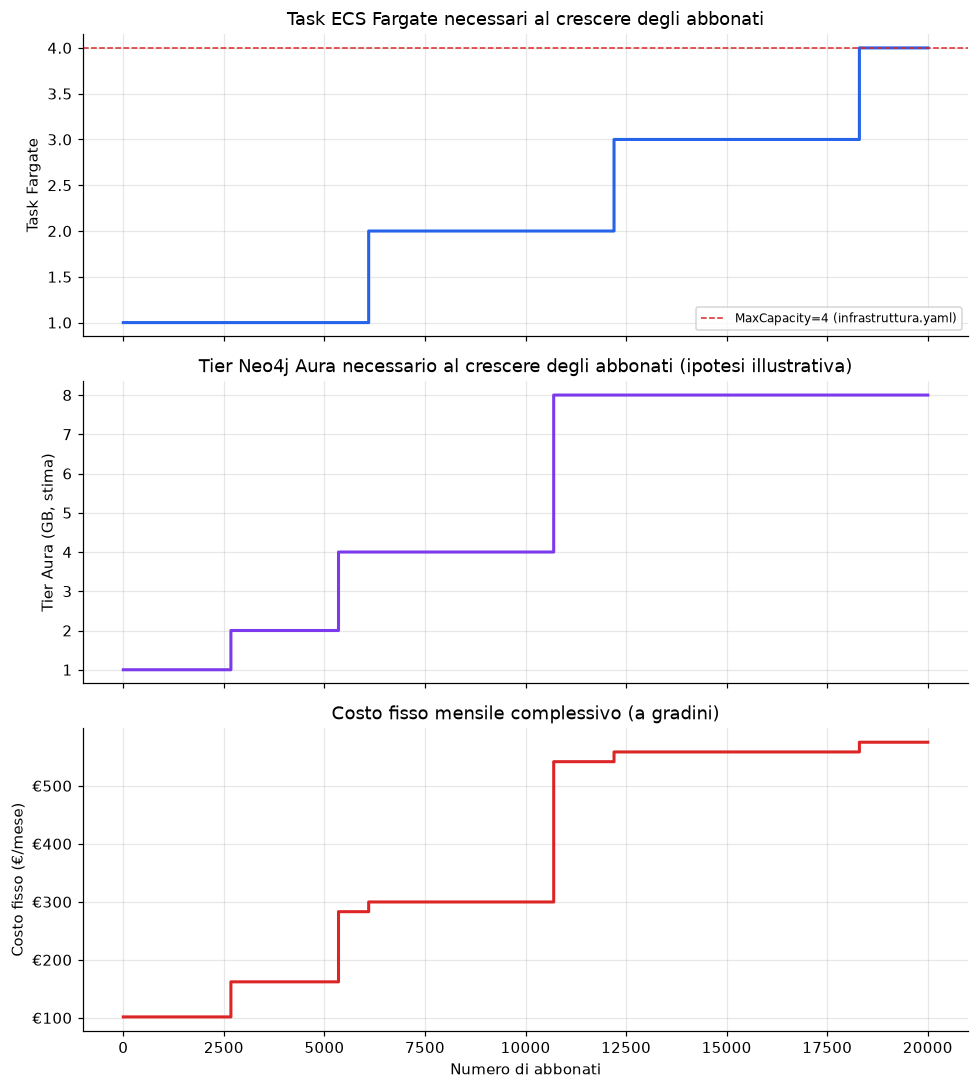

In [10]:
n_fitto = np.arange(0, 20001, 25)
tasks_fitto = [task_fargate_necessari(n) for n in n_fitto]
tier_idx_fitto = []
for n in n_fitto:
    carico = carico_query_aura(n)
    idx = next((i for i, row in AURA_TIER.iterrows()
                if carico <= row["capacita_query_concorrenti (STIMA)"]), len(AURA_TIER) - 1)
    tier_idx_fitto.append(idx)

costo_fisso_fitto_eur = [
    (ALTRI_FISSI_USD + t * COSTO_FARGATE_TASK_USD + AURA_TIER.loc[ti, "costo_usd"]) * FX_USD_EUR
    for t, ti in zip(tasks_fitto, tier_idx_fitto)
]

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].step(n_fitto, tasks_fitto, where="post", color="#2563EB", lw=2)
axes[0].axhline(MAX_TASK_DA_TEMPLATE, color="#DC2626", ls="--", lw=1,
                label="MaxCapacity=4 (infrastruttura.yaml)")
axes[0].set_ylabel("Task Fargate")
axes[0].set_title("Task ECS Fargate necessari al crescere degli abbonati")
axes[0].legend(fontsize=8)

axes[1].step(n_fitto, [AURA_TIER.loc[i, "memoria_gb"] for i in tier_idx_fitto],
             where="post", color="#7C3AED", lw=2)
axes[1].set_ylabel("Tier Aura (GB, stima)")
axes[1].set_title("Tier Neo4j Aura necessario al crescere degli abbonati (ipotesi illustrativa)")

axes[2].step(n_fitto, costo_fisso_fitto_eur, where="post", color="#DC2626", lw=2)
axes[2].set_ylabel("Costo fisso (€/mese)")
axes[2].set_xlabel("Numero di abbonati")
axes[2].set_title("Costo fisso mensile complessivo (a gradini)")
axes[2].yaxis.set_major_formatter(EUR_FMT)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Breakeven realistico, con costi fissi a gradini

Si rifà il conto della sezione 3 ma sostituendo il costo fisso costante con
quello a gradini appena calcolato, su un intervallo di abbonati più ampio
(fino a 20.000) per vedere l'effetto degli scatti di capacità sull'utile.


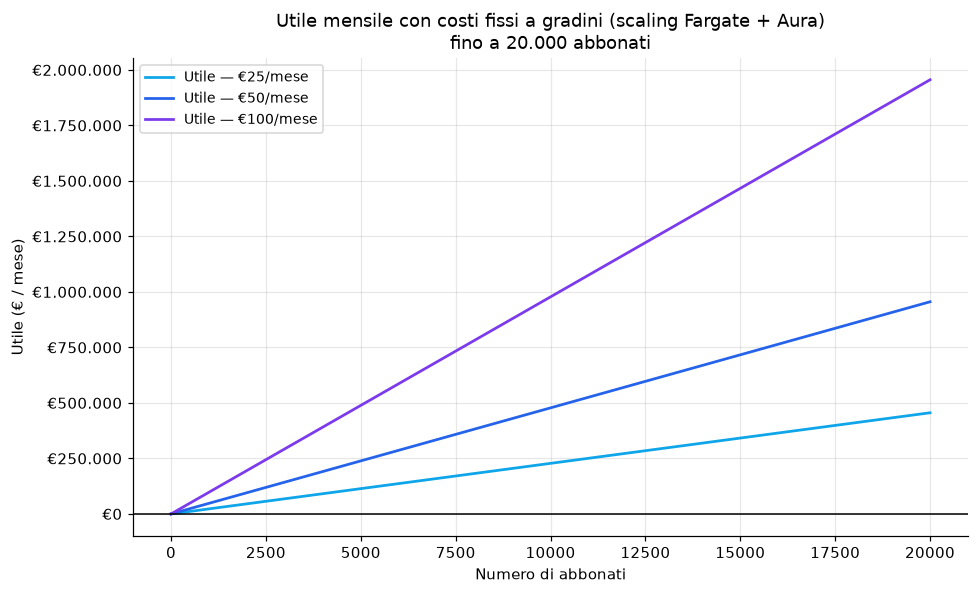

In [11]:
be_scala = pd.DataFrame({"n_abbonati": n_fitto, "costi_totali_eur":
                          np.array(costo_fisso_fitto_eur) + n_fitto * COSTO_VAR_UTENTE_MESE_EUR})
for p in PREZZI_EUR:
    be_scala[f"ricavi_{p}"] = be_scala["n_abbonati"] * p
    be_scala[f"utile_{p}"] = be_scala[f"ricavi_{p}"] - be_scala["costi_totali_eur"]

fig, ax = plt.subplots(figsize=(9, 5.5))
for p in PREZZI_EUR:
    ax.plot(be_scala["n_abbonati"], be_scala[f"utile_{p}"], color=colors[p], lw=1.8,
            label=f"Utile — €{p}/mese")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Numero di abbonati")
ax.set_ylabel("Utile (€ / mese)")
ax.yaxis.set_major_formatter(EUR_FMT)
ax.set_title("Utile mensile con costi fissi a gradini (scaling Fargate + Aura)\nfino a 20.000 abbonati")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Lettura.** Anche tenendo conto degli scatti di capacità, l'utile
resta ampiamente positivo e crescente in tutti e tre gli scenari: i gradini
di costo (qualche centinaio di euro al mese) sono piccoli rispetto ai ricavi
a queste scale. Il punto di pareggio non si sposta in modo apprezzabile — la
capacità AWS/Aura non è il vincolo di questo modello di business, è
un'informazione utile per il piano di crescita (quando budgettare un
upgrade), non per la sostenibilità del prezzo.


## 6. Sintesi e limiti del modello

**Cosa il notebook mostra con buona affidabilità** (numeri misurati nel
repository):
- Il costo variabile per utente/mese è di pochi euro (~€2, dominato da
  Claude), quindi qualunque dei tre prezzi (€25/€50/€100) è ampiamente
  profittevole già con pochissimi abbonati.
- I costi fissi dello stack attuale (1 task Fargate + Aura) sono
  dell'ordine di **~€100/mese**.

**Cosa è un'ipotesi da verificare prima di usare questi numeri per decisioni
vere:**
1. **Tasso di cambio USD→EUR** (0,93) — aggiornare al valore corrente.
2. **Tariffa reale dell'istanza Neo4j Aura** — l'istanza in uso
   (`AURA_INSTANCENAME=My instance` in `.env`) non ha un tier/costo
   confermato nel repository; €65/mese è una stima.
3. **Capacità per tier di Aura** (50/100/200/400 query concorrenti) — è
   un'ipotesi illustrativa (raddoppio memoria/prezzo), non un dato
   pubblicato. Senza un load test reale, la soglia esatta a cui serve
   l'upgrade può essere molto diversa.
4. **Fattore di picco (4×)** e **finestra oraria lavorativa (22gg × 10h)** —
   assunzioni sul pattern d'uso; uno strumento legale potrebbe avere un
   pattern diverso (es. picchi a inizio giornata, uso anche serale).
5. **Costo Claude per messaggio** — la media (~€0,023) è presa da misure di
   benchmark/produzione su domande di test; il mix reale di domande degli
   abbonati potrebbe spostarlo.
6. **Costo per MAU di Cognito oltre la soglia gratuita** — non modellato
   quantitativamente, rilevante solo se gli abbonati superano diverse
   decine di migliaia.

Il valore del notebook non è "il numero esatto", ma **la struttura del
ragionamento**: cambiando le celle di configurazione nelle sezioni 1 e 4.1
(FX, prezzi, driver di costo, parametri di concorrenza) tutte le tabelle e i
grafici a valle si aggiornano.
